# Informe integrado: PokeAPI + Smogon

Este informe presenta el grafo integrado como un motor de razonamiento
competitivo. Una base de datos permite preguntar "¿qué datos tiene este
Pokémon?"; el grafo permite preguntar "¿por qué encaja en una estrategia, qué
sinergias genera, qué alternativas existen y qué patrones competitivos emergen?".

Para eso se integra la estructura de PokeAPI (tipos, movimientos, evolución,
crianza, habilidades y estadísticas) con una capa competitiva de Smogon para
Gen 9 OU / Scarlet & Violet: uso, movimientos usados, objetos, habilidades,
compañeros y respuestas defensivas.


## 1. Introducción y motivación

El objetivo no es solo listar atributos, sino conectar entidades y relaciones
para apoyar decisiones de construcción de equipos. El grafo permite combinar:

- Estructura base de PokeAPI: especies, tipos, movimientos, evolución, crianza.
- Capa competitiva de Smogon: uso real, movimientos usados, objetos, habilidades,
  compañeros y respuestas defensivas.
- Algoritmos de grafo: centralidad, comunidades, similitud estructural y rutas
  explicativas.

La lectura estratégica del informe se organiza en seis preguntas de
investigación. Cada bloque mantiene consultas livianas o proyecciones ya usadas
por el reporte, de modo que el cuaderno siga ejecutando dentro del límite de
120 segundos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from IPython.display import display, Markdown

driver = GraphDatabase.driver('bolt://localhost:7687', auth=None)

def df(query):
    with driver.session() as session:
        return pd.DataFrame([r.data() for r in session.run(query)])

def run(query):
    with driver.session() as session:
        session.run(query)

def lista_texto(valores, max_items=3):
    valores = [str(v) for v in list(valores)[:max_items] if pd.notna(v)]
    if not valores:
        return "sin resultados visibles"
    if len(valores) == 1:
        return valores[0]
    return ", ".join(valores[:-1]) + " y " + valores[-1]

print('Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.')


Conexión a Neo4j establecida. Usa df(query) para ejecutar Cypher y run(query) para comandos de estado.


## 2. Modelo del grafo integrado

El grafo representa nodos como `Pokemon`, `Species`, `Move`, `Type`,
`EggGroup`, `Format`, `Item` y `Ability`. Entre sus relaciones principales
están `CAN_LEARN`, `HAS_TYPE`, `COMPATIBLE`, `RUNS_MOVE`, `HOLDS_ITEM`,
`USES_ABILITY`, `TEAMMATE_OF` y `CHECKED_BY`.

La clave analítica está en cruzar capas. Un Pokémon no se interpreta solo por
sus atributos, sino por sus conexiones: qué movimientos usa, con quién aparece,
qué tipos cubre, qué lo amenaza y qué otros Pokémon ocupan posiciones parecidas.


In [2]:
labels = df('MATCH (n) UNWIND labels(n) AS label RETURN label, count(*) AS cantidad ORDER BY cantidad DESC')
display(labels)


,label,cantidad
0,Encounter,69714
1,Name,56842
2,Item,2176
3,PokemonForm,1579
4,Pokemon,1351
5,LocationArea,1249
6,Location,1096
7,Species,1025
8,Move,937
9,EvolutionCondition,550


Esta tabla ayuda a entender de qué está hecho el grafo antes de entrar en
los análisis competitivos. Cada fila corresponde a una clase de entidad, como
Pokémon, movimientos, tipos, habilidades, objetos o formatos. Un número alto
indica que esa capa tiene muchos nodos disponibles para ser conectados con el
resto del modelo.

La utilidad de esta mirada inicial es contextual. El reporte no razona desde una
tabla aislada, sino desde varias capas conectadas entre sí. Sin embargo, el
tamaño de una capa no significa automáticamente que sea la más importante para
competir; solo muestra cuánta información contiene esa parte del grafo.


In [3]:
rels = df('MATCH ()-[r]->() RETURN type(r) AS relacion, count(*) AS cantidad ORDER BY cantidad DESC')
display(rels)


,relacion,cantidad
0,CAN_LEARN,635905
1,COMPATIBLE,71232
2,HAS_ENCOUNTER,69714
3,AT_AREA,69714
4,HAS_NAME,56842
5,HAS_STAT,8100
6,HAS_ABILITY,2937
7,TEAMMATE_OF,2796
8,RUNS_MOVE,2344
9,HAS_TYPE,2115


Esta segunda tabla muestra las conexiones disponibles entre entidades. En
un grafo, las relaciones son tan importantes como los nodos, porque permiten
pasar de preguntas descriptivas a preguntas estratégicas. Por ejemplo,
`TEAMMATE_OF` conecta Pokémon que aparecen juntos en equipos, `RUNS_MOVE`
relaciona Pokémon con movimientos usados en el metajuego y `HAS_TYPE` permite
razonar sobre perfiles ofensivos y defensivos.

El conteo sirve para saber qué relaciones tienen más presencia en los datos,
pero debe leerse con cuidado. Una relación muy frecuente no siempre es la más
decisiva competitivamente: su valor depende de la pregunta que se esté
respondiendo y del contexto del formato analizado.


## 3. Preguntas de investigación y correspondencia analítica

Las preguntas que guían el reporte son:

1. ¿Qué Pokémon, movimientos, habilidades u objetos son más centrales dentro del grafo competitivo?
2. ¿Qué Pokémon pueden funcionar como sustitutos estratégicos de otros al armar un equipo?
3. ¿Qué tipos o combinaciones de tipos ofrecen mejores perfiles ofensivos y defensivos?
4. ¿Qué cores competitivos emergen en la red `TEAMMATE_OF` y qué los caracteriza?
5. ¿Qué cadenas de relaciones explican por qué un Pokémon encaja en una estrategia competitiva?
6. ¿Puede el grafo descubrir patrones competitivos que no aparecen claramente en un análisis tabular?

**Correspondencia entre preguntas, análisis y utilidad**

| Pregunta | Análisis usado | Parte del grafo | Utilidad estratégica | Limitación |
|---|---|---|---|---|
| 1. Centralidad competitiva | PageRank en `TEAMMATE_OF` y frecuencia de recursos usados | `Pokemon`, `Move`, `Ability`, `Item`, `Format` | Priorizar amenazas, recursos de preparación y piezas alrededor de las cuales se organiza el metajuego | La centralidad depende de los datos de uso de Smogon cargados y no reemplaza el juicio competitivo |
| 2. Sustitutos estratégicos | Similitud por repertorio de movimientos y tipos compartidos | `Pokemon`, `Move`, `Type` | Proponer alternativas cuando una pieza no está disponible o no calza con el equipo | No modela EVs, naturalezas, objetos ni rol exacto en batalla |
| 3. Perfiles ofensivos y defensivos | PageRank del cuadro de tipos y resumen defensivo por combinaciones | `Type`, `EFFECTIVENESS`, `Pokemon` | Diseñar cobertura ofensiva, respuestas defensivas y perfiles de resistencia | No incorpora habilidades que alteran inmunidades ni condiciones dinámicas de combate |
| 4. Cores competitivos | Louvain sobre la red `TEAMMATE_OF` | `Pokemon`, `TEAMMATE_OF`, `RUNS_MOVE`, `USED_IN` | Identificar grupos de Pokémon que aparecen juntos y caracterizar su plan de juego | Una comunidad sugiere core, pero no prueba por sí sola un arquetipo cerrado |
| 5. Cadenas explicativas | Rutas acotadas entre Pokémon, movimientos, tipos y compañeros | `Pokemon`, `Move`, `Type`, `TEAMMATE_OF` | Explicar por qué una pieza encaja en una estrategia y qué sinergias activa | Son ejemplos interpretables, no una enumeración exhaustiva de todos los caminos |
| 6. Patrones no tabulares | Comparación de métricas tabulares y métricas con señales de grafo | Grafo integrado y variables derivadas | Evaluar si las relaciones agregan señal frente a mirar atributos aislados | Las métricas altas deben leerse con cautela cuando la capa competitiva está cerca de la etiqueta |

**Alcance temporal**

El análisis competitivo se basa en Gen 9 OU / Scarlet & Violet / Smogon. El
metajuego puede cambiar: Pokémon Champions u otros cambios de reglas podrían
alterar cores, sustitutos, respuestas defensivas y viabilidad. Actualizar la capa competitiva
con datos de Pokémon Champions debe quedar como trabajo futuro.


## 4. Análisis estratégico del grafo

Los siguientes bloques responden directamente a las preguntas de investigación.
Las consultas priorizan resultados interpretables y acotados; cuando se usa GDS,
se reutilizan proyecciones livianas que ya forman parte del reporte ejecutable.


### 4.1 Pokémon más influyentes en la red de equipos

Primero se proyecta la red `TEAMMATE_OF` como grafo no dirigido. PageRank
identifica Pokémon influyentes. En lenguaje simple, PageRank mide si un Pokémon
está conectado con otros Pokémon que también son importantes dentro de la red.


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('teammates', false)"


,pokemon,pagerank_competitivo,uso_smogon
0,great-tusk,5.07024,33.73
1,kingambit,4.24016,25.27
2,gholdengo,4.15018,27.63
3,dragapult,3.56775,14.59
4,corviknight,3.52335,12.56
5,iron-treads,3.51203,10.62
6,hatterene,3.37569,10.97
7,dragonite,3.27258,25.35
8,gliscor,3.24983,19.39
9,glimmora,3.05000,9.23


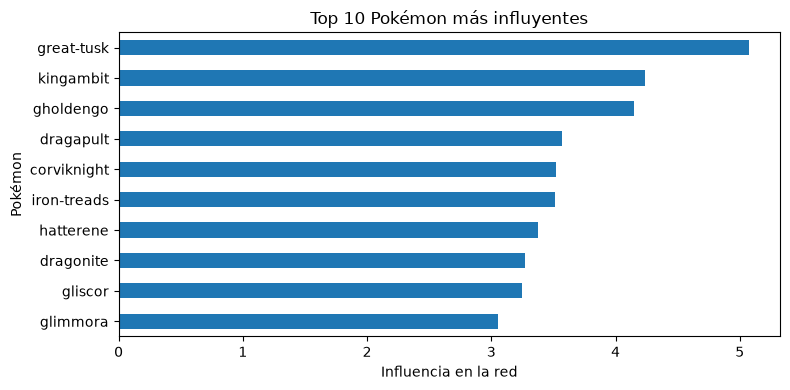

En los primeros lugares aparecen great-tusk, kingambit y gholdengo. Estos Pokémon quedan arriba porque no solo tienen conexiones en la red de compañeros, sino porque esas conexiones los acercan a otras piezas relevantes. En términos estratégicos, conviene leerlos como posibles ejes del formato: piezas que ayudan a unir equipos, formar cores o condicionar la preparación defensiva. El ranking no prueba que sean los mejores en combate, pero sí señala que ocupan posiciones estructurales en la red analizada.

In [4]:
run("CALL gds.graph.drop('teammates', false)")
run('''
CALL gds.graph.project(
  'teammates',
  'Pokemon',
  {
    TEAMMATE_OF: {
      orientation: 'UNDIRECTED'
    }
  }
)
''')
res = df('''
CALL gds.pageRank.stream('teammates') YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS p, score
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
RETURN p.identifier AS pokemon,
       round(score * 100000) / 100000.0 AS pagerank_competitivo,
       round(coalesce(u.usage, 0.0) * 100) / 100.0 AS uso_smogon
ORDER BY pagerank_competitivo DESC
LIMIT 20
''')
display(res)
if not res.empty:
    ax = res.head(10).sort_values('pagerank_competitivo').plot.barh(
        x='pokemon', y='pagerank_competitivo', legend=False, figsize=(8, 4)
    )
    ax.set_title('Top 10 Pokémon más influyentes')
    ax.set_xlabel('Influencia en la red')
    ax.set_ylabel('Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En los primeros lugares aparecen {nombres}. Estos Pokémon quedan arriba porque no solo tienen conexiones en la red de compañeros, "
        "sino porque esas conexiones los acercan a otras piezas relevantes. En términos estratégicos, conviene leerlos como posibles ejes del formato: "
        "piezas que ayudan a unir equipos, formar cores o condicionar la preparación defensiva. El ranking no prueba que sean los mejores en combate, "
        "pero sí señala que ocupan posiciones estructurales en la red analizada."
    ))


En este análisis, la influencia no debe entenderse simplemente como
popularidad o fuerza individual. Aquí se mide como centralidad dentro de la red
de compañeros de equipo: un Pokémon obtiene un valor más alto cuando aparece
conectado con muchas combinaciones relevantes y, especialmente, cuando sus
conexiones también involucran a otros Pokémon importantes dentro de la red. Por
eso, un valor mayor no significa necesariamente que ese Pokémon sea mejor en
batalla, sino que cumple un rol más estructural en los equipos observados.

La tabla y el gráfico permiten identificar piezas que ayudan a organizar el
metajuego competitivo. Si un Pokémon aparece con alta centralidad, puede ser
porque encaja en muchos equipos distintos, habilita estrategias comunes o forma
parte de cores usados con frecuencia. En términos prácticos, estos resultados
sirven para decidir qué amenazas conviene estudiar primero al preparar
respuestas defensivas o al analizar cómo se construyen equipos en el formato.

Esta medida depende de las relaciones cargadas desde Smogon y no incorpora por
sí sola detalles como objetos, EVs, movimientos específicos o decisiones dentro
de una partida. Por eso funciona como una señal inicial de influencia
estratégica, pero no reemplaza un análisis competitivo completo.


In [5]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (p)-[:USES_ABILITY]->(ab:Ability)
OPTIONAL MATCH (p)-[:HOLDS_ITEM]->(it:Item)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       collect(DISTINCT m.identifier)[..5] AS movimientos_usados,
       collect(DISTINCT ab.identifier)[..3] AS habilidades_usadas,
       collect(DISTINCT it.identifier)[..3] AS objetos_usados
ORDER BY uso_smogon DESC
LIMIT 15
'''
res = df(query)
display(res)
if not res.empty:
    nombres = lista_texto(res['pokemon'])
    display(Markdown(
        f"En esta tabla destacan {nombres}, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. "
        "La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso "
        "con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo."
    ))


,pokemon,uso_smogon,movimientos_usados,habilidades_usadas,objetos_usados
0,great-tusk,33.73,"[headlong-rush, knock-off, taunt, stealth-rock...",[protosynthesis],"[choice-band, heavy-duty-boots, leftovers]"
1,zamazenta,28.68,"[body-press, stone-edge, reflect, close-combat...",[dauntless-shield],"[heavy-duty-boots, leftovers, choice-scarf]"
2,gholdengo,27.63,"[psyshock, dazzling-gleam, hex, thunder-wave, ...",[good-as-gold],"[leftovers, shuca-berry, metal-coat]"
3,dragonite,25.35,"[dragon-claw, roost, outrage, low-kick, extrem...",[multiscale],"[loaded-dice, choice-band, silk-scarf]"
4,kingambit,25.27,"[low-kick, swords-dance, iron-head, sucker-pun...",[supreme-overlord],"[shuca-berry, black-glasses, leftovers]"
5,gliscor,19.39,"[earthquake, protect, stealth-rock, agility, t...",[poison-heal],[toxic-orb]
6,ting-lu,17.42,"[spikes, earthquake, protect, stealth-rock, ta...",[vessel-of-ruin],"[leftovers, rocky-helmet, red-card]"
7,kyurem,17.04,"[ice-beam, focus-blast, earth-power, blizzard,...",[pressure],"[heavy-duty-boots, choice-specs, loaded-dice]"
8,ogerpon-wellspring-mask,16.47,"[substitute, encore, taunt, synthesis, trailbl...",[water-absorb],[wellspring-mask]
9,dragapult,14.59,"[curse, draco-meteor, dragon-darts, quick-atta...","[clear-body, infiltrator]","[choice-band, choice-specs, air-balloon]"


En esta tabla destacan great-tusk, zamazenta y gholdengo, junto con una muestra de los movimientos, habilidades y objetos que aparecen asociados a ellos. La lectura relevante no es solo que estos Pokémon se usen, sino qué herramientas explican parte de ese uso. Si un Pokémon combina alto uso con recursos frecuentes, puede ser una amenaza que conviene preparar o una pieza que ayuda a sostener planes comunes de equipo.

Esta tabla complementa la centralidad mostrando parte del kit competitivo de
los Pokémon más usados: movimientos, habilidades y objetos asociados. La idea es
pasar de "este Pokémon es importante" a una lectura más concreta sobre cómo
aporta valor dentro de un equipo. Un Pokémon puede ser central por su capacidad
de presionar, resistir, apoyar a compañeros o habilitar una secuencia común de
juego.

El resultado es útil porque permite conectar influencia con herramientas
observables. Si ciertos movimientos u objetos aparecen repetidamente, eso puede
orientar la preparación de respuestas defensivas y ayudar a entender qué recursos
definen el metajuego. Aun así, la tabla muestra una síntesis y no todos los
conjuntos posibles, por lo que debe leerse como una guía inicial y no como una
descripción completa de cada set competitivo.


### 4.2 Pokémon que podrían cumplir funciones parecidas

Jaccard es una forma simple de medir cuánto se parecen dos conjuntos. Aquí se
usa para comparar repertorios de movimientos. Además, se excluyen Pokémon de una
misma línea evolutiva y se agregan diferencias de estadísticas para evaluar si
la sustitución parece realista.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONAL MA

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=7, offset=738>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 738, 'line': 16, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONAL 

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=16, column=16, offset=747>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 747, 'line': 16, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nORDER BY movepool_size DESC\nLIMIT 50\nMATCH (p)-[:IS_SPECIES]->(sp:Species)\nOPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)\nWITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos\nOPTIONA

,pokemon_a,pokemon_b,movimientos_compartidos,similitud_jaccard,tipos_compartidos,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats
0,nidoqueen,nidoking,125,0.880,"[ground, poison]",505,505,0,9.67
1,clefable,wigglytuff,132,0.714,[fairy],483,435,48,23.00
2,clefairy,jigglypuff,128,0.707,[fairy],323,270,53,23.83
3,tyranitar,aggron,106,0.697,[rock],600,530,70,35.00
4,clefable,chansey,126,0.692,[],483,450,33,62.17
5,clefairy,wigglytuff,128,0.688,[fairy],323,435,112,24.67
6,clefable,jigglypuff,127,0.686,[fairy],483,270,213,42.17
7,aggron,rhyperior,102,0.680,[rock],530,535,5,24.17
8,clefairy,chansey,123,0.676,[],323,450,127,57.17
9,wigglytuff,chansey,118,0.659,[normal],435,450,15,54.17


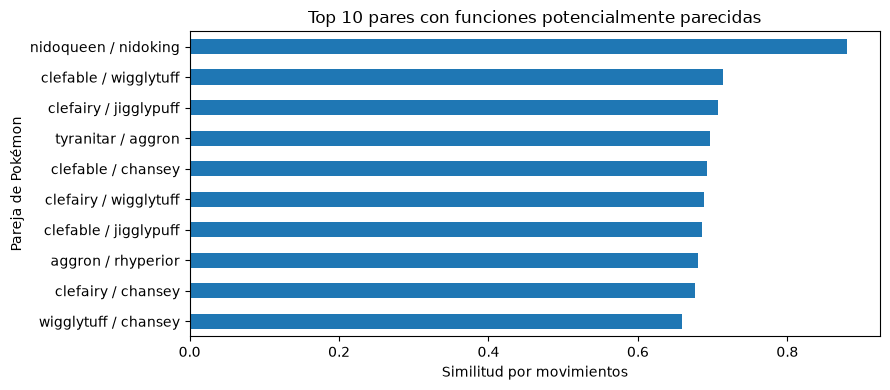

Entre los pares más altos aparecen nidoqueen / nidoking (Jaccard 0.88, diferencia BST 0); clefable / wigglytuff (Jaccard 0.714, diferencia BST 48); clefairy / jigglypuff (Jaccard 0.707, diferencia BST 53). Estos casos suben en la tabla porque comparten muchos movimientos y, al mismo tiempo, permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate.

In [6]:
query = '''MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size
ORDER BY movepool_size DESC
LIMIT 50
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movepool_size, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movepool_size, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movepool_size, tipos:tipos, bst:bst, stats:stats}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 10
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
WITH a, b, inter, jaccard, diferencias_stats,
     (a.conexiones_team + b.conexiones_team) AS conexiones_team_total
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       [tipo IN a.tipos WHERE tipo IN b.tipos] AS tipos_compartidos,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats
ORDER BY similitud_jaccard DESC, movimientos_compartidos DESC
LIMIT 20
'''
res = df(query)
display(res)
if not res.empty:
    graf = res.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 pares con funciones potencialmente parecidas')
    ax.set_xlabel('Similitud por movimientos')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
if not res.empty:
    top = res.head(3).copy()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (Jaccard {r.similitud_jaccard}, diferencia BST {r.diferencia_bst})"
        for r in top.itertuples()
    )
    display(Markdown(
        f"Entre los pares más altos aparecen {pares}. Estos casos suben en la tabla porque comparten muchos movimientos y, al mismo tiempo, "
        "permiten comparar si la diferencia de estadísticas base hace plausible la sustitución. Una pareja con alta similitud pero diferencia BST grande "
        "debe revisarse con más cuidado: puede parecerse en herramientas, pero no necesariamente cumplir el mismo rol en combate."
    ))


La similitud entre Pokémon se calcula comparando sus repertorios de
movimientos. En términos simples, dos Pokémon aparecen más arriba cuando
comparten muchas herramientas posibles. Esto no significa que sean idénticos,
pero sí que podrían cumplir funciones parecidas, como aportar una cobertura
similar, usar movimientos de apoyo comparables o adaptarse a planes de equipo
relacionados.

La comparación de estadísticas agrega una segunda capa de lectura. El total de
estadísticas base (`bst_a` y `bst_b`) y las diferencias promedio ayudan a evaluar
si la sustitución es realista: dos Pokémon pueden aprender movimientos parecidos,
pero si uno tiene mucha más velocidad, bulk o poder ofensivo que el otro, la
alternativa puede funcionar peor en la práctica. También se excluyen evoluciones
y pre-evoluciones, porque normalmente no son sustitutos estratégicos útiles,
sino versiones relacionadas de una misma línea.

El resultado debe entenderse como una lista de candidatos para revisar, no como
una recomendación automática. Todavía faltan factores importantes como EVs,
naturalezas, objetos, habilidades específicas y rol dentro del equipo. El valor
del grafo está en reducir el espacio de búsqueda y proponer comparaciones
razonables que luego requieren juicio competitivo.


#### Sustitutos con mayor señal competitiva

La tabla anterior busca parecido funcional. Esta segunda tabla agrega una
exigencia adicional: al menos uno de los dos Pokémon debe tener presencia en la
capa competitiva, ya sea por uso en el formato o por conexiones en la red de
compañeros `TEAMMATE_OF`. Así se priorizan alternativas que no solo se parecen
por movimientos y estadísticas, sino que además tienen alguna señal de relevancia
en el grafo competitivo.


Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=2, column=26, offset=84>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 84, 'line': 2, 'column': 26}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_size, 

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=7, offset=1167>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1167, 'line': 21, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_si

Received notification from DBMS server: <GqlStatusObject gql_status='01N02', status_description='warn: feature deprecated without replacement. id is deprecated and will be removed without a replacement.', position=<SummaryInputPosition line=21, column=16, offset=1176>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1176, 'line': 21, 'column': 16}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)\nWITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size\nOPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)\nWITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team\nOPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})\nWITH p, moves, movepool_

,pokemon_a,pokemon_b,pokemon_competitivo,movimientos_compartidos,similitud_jaccard,bst_a,bst_b,diferencia_bst,diferencia_promedio_stats,conexiones_team_a,conexiones_team_b,conexiones_team_total
0,clefable,blissey,clefable / blissey,119,0.654,483,540,57,58.83,32,29,61
1,zapdos,moltres,zapdos / moltres,64,0.593,580,580,0,5.00,45,26,71
2,great-tusk,iron-treads,great-tusk / iron-treads,40,0.580,570,570,0,18.33,125,88,213
3,torkoal,heatran,torkoal / heatran,60,0.526,470,600,130,33.00,29,41,70
4,tyranitar,garchomp,tyranitar / garchomp,76,0.500,600,600,0,16.33,45,54,99
5,dragonite,tyranitar,dragonite / tyranitar,88,0.476,600,600,0,8.00,79,45,124
6,alomomola,primarina,alomomola / primarina,52,0.473,470,530,60,42.33,61,36,97
7,scizor,gliscor,scizor / gliscor,67,0.469,500,510,10,18.33,42,81,123
8,garchomp,excadrill,garchomp / excadrill,53,0.457,600,508,92,17.67,54,36,90
9,blaziken,hawlucha,blaziken / hawlucha,72,0.453,530,500,30,19.33,43,22,65


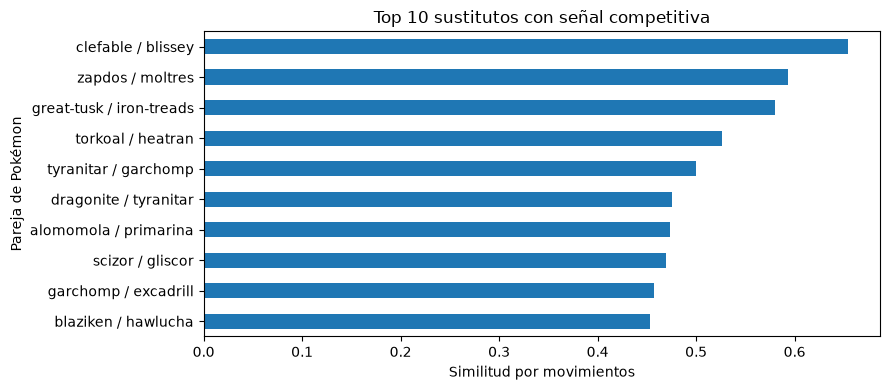

Con la restricción competitiva, los primeros pares son clefable / blissey (señal: clefable / blissey, conexiones 32+29); zapdos / moltres (señal: zapdos / moltres, conexiones 45+26); great-tusk / iron-treads (señal: great-tusk / iron-treads, conexiones 125+88). Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. Por eso estos pares son candidatos más cercanos a una discusión de construcción real.

In [7]:
query = '''MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
WITH p, collect(DISTINCT id(m)) AS moves, count(DISTINCT m) AS movepool_size
OPTIONAL MATCH (p)-[tm:TEAMMATE_OF]-(:Pokemon)
WITH p, moves, movepool_size, count(DISTINCT tm) AS conexiones_team
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, moves, movepool_size, conexiones_team, coalesce(max(u.usage), 0.0) AS uso_smogon
ORDER BY conexiones_team DESC, uso_smogon DESC, movepool_size DESC
LIMIT 60
MATCH (p)-[:IS_SPECIES]->(sp:Species)
OPTIONAL MATCH (p)-[:HAS_TYPE]->(t:Type)
WITH p, sp, moves, movepool_size, conexiones_team, uso_smogon, collect(DISTINCT t.identifier) AS tipos
OPTIONAL MATCH (p)-[hs:HAS_STAT]->(st:Stat)
WITH p, sp, moves, movepool_size, conexiones_team, uso_smogon, tipos,
     sum(coalesce(hs.base_stat, 0)) AS bst,
     collect({stat: st.identifier, valor: coalesce(hs.base_stat, 0)}) AS stats
WITH collect({p:p, sp:sp, moves:moves, size:movepool_size, tipos:tipos, bst:bst, stats:stats,
              conexiones_team:conexiones_team, uso_smogon:uso_smogon}) AS pokes
UNWIND pokes AS a
UNWIND pokes AS b
WITH a, b, a.p AS pa, b.p AS pb, a.sp AS spa, b.sp AS spb
WHERE id(pa) < id(pb)
  AND (a.conexiones_team > 0 OR b.conexiones_team > 0 OR a.uso_smogon > 0 OR b.uso_smogon > 0)
  AND NOT EXISTS {
    MATCH (spa)-[:EVOLVES_TO*1..10]-(spb)
  }
WITH a, b, size([x IN a.moves WHERE x IN b.moves]) AS inter
WHERE inter >= 10
WITH a, b, inter,
     toFloat(inter) / (a.size + b.size - inter) AS jaccard
WITH a, b, inter, jaccard,
     [sa IN a.stats
      WHERE any(sb IN b.stats WHERE sb.stat = sa.stat)
      | abs(sa.valor - head([sb IN b.stats WHERE sb.stat = sa.stat | sb.valor]))] AS diferencias_stats
WITH a, b, inter, jaccard, diferencias_stats,
     a.conexiones_team + b.conexiones_team AS conexiones_team_total
RETURN a.p.identifier AS pokemon_a,
       b.p.identifier AS pokemon_b,
       CASE
         WHEN (a.conexiones_team > 0 OR a.uso_smogon > 0) AND (b.conexiones_team > 0 OR b.uso_smogon > 0)
           THEN a.p.identifier + ' / ' + b.p.identifier
         WHEN a.conexiones_team > 0 OR a.uso_smogon > 0 THEN a.p.identifier
         ELSE b.p.identifier
       END AS pokemon_competitivo,
       inter AS movimientos_compartidos,
       round(jaccard * 1000) / 1000.0 AS similitud_jaccard,
       a.bst AS bst_a,
       b.bst AS bst_b,
       abs(a.bst - b.bst) AS diferencia_bst,
       CASE WHEN size(diferencias_stats) = 0 THEN null
            ELSE round((reduce(total = 0.0, d IN diferencias_stats | total + d) / size(diferencias_stats)) * 100) / 100.0
       END AS diferencia_promedio_stats,
       a.conexiones_team AS conexiones_team_a,
       b.conexiones_team AS conexiones_team_b,
       conexiones_team_total AS conexiones_team_total
ORDER BY similitud_jaccard DESC, conexiones_team_total DESC, movimientos_compartidos DESC
LIMIT 20
'''
res_comp = df(query)
display(res_comp)
if not res_comp.empty:
    graf = res_comp.head(10).copy()
    graf['pareja'] = graf['pokemon_a'] + ' / ' + graf['pokemon_b']
    ax = graf.sort_values('similitud_jaccard').plot.barh(
        x='pareja', y='similitud_jaccard', legend=False, figsize=(9, 4)
    )
    ax.set_title('Top 10 sustitutos con señal competitiva')
    ax.set_xlabel('Similitud por movimientos')
    ax.set_ylabel('Pareja de Pokémon')
    plt.tight_layout()
    plt.show()
    pares = "; ".join(
        f"{r.pokemon_a} / {r.pokemon_b} (señal: {r.pokemon_competitivo}, conexiones {r.conexiones_team_a}+{r.conexiones_team_b})"
        for r in res_comp.head(3).itertuples()
    )
    display(Markdown(
        f"Con la restricción competitiva, los primeros pares son {pares}. Esta tabla es más exigente que la anterior porque no basta con compartir movimientos: "
        "al menos una de las dos piezas debe estar conectada con la capa competitiva, ya sea por presencia en equipos o por vínculos en `TEAMMATE_OF`. "
        "Por eso estos pares son candidatos más cercanos a una discusión de construcción real."
    ))


Esta segunda tabla no reemplaza a la primera: la complementa. La primera
permite descubrir parecidos funcionales amplios, mientras que esta filtra esos
parecidos hacia casos con mayor evidencia competitiva. Si un par mantiene alta
similitud por movimientos, diferencias razonables de estadísticas y además uno
de sus integrantes aparece conectado en la red de equipos, la comparación se
vuelve más interesante para discutir alternativas reales.

La lectura sigue requiriendo cautela. Las conexiones en `TEAMMATE_OF` indican
presencia relacional en el metajuego cargado, pero no explican por sí solas el
conjunto, el objeto ni el rol exacto. Por eso la tabla sirve para priorizar pares
que merecen revisión, no para afirmar automáticamente que un Pokémon reemplaza
al otro en cualquier equipo.


### 4.3 Tipos y combinaciones con mejores perfiles

El cuadro de tipos se interpreta como red dirigida de efectividad. La centralidad
ofensiva identifica tipos que se ubican en posiciones influyentes dentro de esa
red, mientras que el resumen defensivo evalúa combinaciones reales presentes en
Pokémon del grafo.


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('typechart', false)"


,tipo,centralidad_ofensiva
0,fighting,0.96124
1,flying,0.96124
2,poison,0.96124
3,ground,0.96124
4,rock,0.96124
5,bug,0.96124
6,ghost,0.96124
7,steel,0.96124
8,fire,0.96124
9,water,0.96124


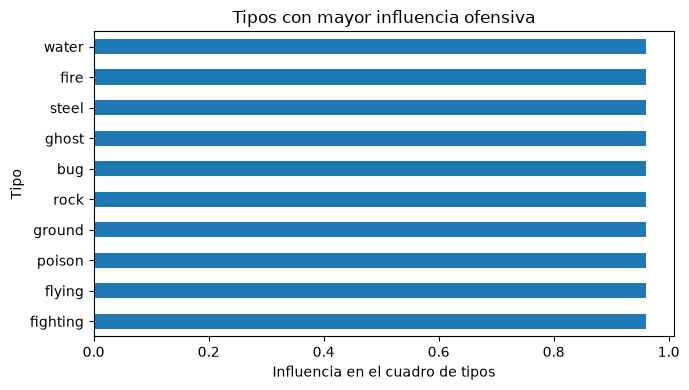

En el ranking ofensivo aparecen arriba tipos como fighting, flying y poison. Estos tipos destacan porque ocupan posiciones influyentes dentro de la red de efectividades, no solo porque tengan una ventaja puntual. En la práctica, esto sugiere que conviene revisar qué Pokémon aprovechan bien esos tipos y qué respuestas defensivas necesita un equipo para no quedar demasiado expuesto frente a esa presión.

In [8]:
run("CALL gds.graph.drop('typechart', false)")
run('''
CALL gds.graph.project(
  'typechart',
  'Type',
  {
    EFFECTIVENESS: {
      orientation: 'NATURAL'
    }
  }
)
''')
res = df('''
CALL gds.pageRank.stream('typechart') YIELD nodeId, score
RETURN gds.util.asNode(nodeId).identifier AS tipo,
       round(score * 100000) / 100000.0 AS centralidad_ofensiva
ORDER BY centralidad_ofensiva DESC
LIMIT 12
''')
display(res)
if not res.empty:
    ax = res.head(10).sort_values('centralidad_ofensiva').plot.barh(
        x='tipo', y='centralidad_ofensiva', legend=False, figsize=(7, 4)
    )
    ax.set_title('Tipos con mayor influencia ofensiva')
    ax.set_xlabel('Influencia en el cuadro de tipos')
    ax.set_ylabel('Tipo')
    plt.tight_layout()
    plt.show()
if not res.empty:
    tipos = lista_texto(res['tipo'])
    display(Markdown(
        f"En el ranking ofensivo aparecen arriba tipos como {tipos}. Estos tipos destacan porque ocupan posiciones influyentes dentro de la red de efectividades, "
        "no solo porque tengan una ventaja puntual. En la práctica, esto sugiere que conviene revisar qué Pokémon aprovechan bien esos tipos y qué respuestas "
        "defensivas necesita un equipo para no quedar demasiado expuesto frente a esa presión."
    ))


En esta sección, la influencia ofensiva de un tipo se obtiene desde la red
de efectividades. Un tipo queda más arriba cuando ocupa una posición relevante
en esa red, no solo cuando tiene una ventaja aislada contra otro tipo. Por eso,
el ranking debe leerse como una señal de presión estructural: muestra qué tipos
participan con más fuerza en las relaciones de ventaja del cuadro de tipos.

Esta información ayuda a pensar coberturas ofensivas y resistencias necesarias
al construir equipos. Si un tipo aparece alto, puede convenir revisar qué
Pokémon lo usan bien, qué compañeros lo apoyan y qué respuestas defensivas son
necesarias. La limitación es que el análisis trabaja solo con tipos: no incorpora
daño real, habilidades, objetos, precisión, prioridad ni el contexto de una
partida.


In [9]:
query = '''
MATCH (p:Pokemon {is_default:true})-[:HAS_TYPE]->(def:Type)
WITH p, collect(DISTINCT def) AS defensas
MATCH (atk:Type)
OPTIONAL MATCH (atk)-[e:EFFECTIVENESS]->(d:Type)
WHERE d IN defensas
WITH p, defensas, atk,
     reduce(mult = 1.0, factor IN collect(coalesce(e.factor, 100) / 100.0) | mult * factor) AS multiplicador
WITH [d IN defensas | d.identifier] AS combinacion,
     count(CASE WHEN multiplicador = 0.0 THEN 1 END) AS inmunidades,
     count(CASE WHEN multiplicador > 0.0 AND multiplicador < 1.0 THEN 1 END) AS resistencias,
     count(CASE WHEN multiplicador > 1.0 THEN 1 END) AS debilidades
RETURN combinacion,
       count(*) AS pokemon_con_combinacion,
       round(avg(inmunidades) * 100) / 100.0 AS inmunidades_promedio,
       round(avg(resistencias) * 100) / 100.0 AS resistencias_promedio,
       round(avg(debilidades) * 100) / 100.0 AS debilidades_promedio
ORDER BY (inmunidades_promedio + resistencias_promedio) DESC, debilidades_promedio ASC
LIMIT 15
'''
res = df(query)
display(res)
if not res.empty:
    combos = lista_texto(res['combinacion'].apply(lambda xs: " / ".join(xs) if isinstance(xs, list) else xs))
    display(Markdown(
        f"Entre las combinaciones defensivas mejor ubicadas aparecen {combos}. Estas combinaciones quedan arriba porque acumulan más resistencias o inmunidades "
        "y reducen la cantidad de debilidades visibles en el cuadro de tipos. La lectura estratégica es que pueden servir como puntos de apoyo para entrar al campo "
        "o cubrir amenazas, aunque la viabilidad real depende también del Pokémon concreto que tenga esa combinación."
    ))


,combinacion,pokemon_con_combinacion,inmunidades_promedio,resistencias_promedio,debilidades_promedio
0,[water],1,0.0,296.0,148.0
1,[fire],1,0.0,216.0,108.0
2,[grass],1,0.0,188.0,235.0
3,[steel],1,10.0,100.0,30.0
4,[electric],1,0.0,105.0,35.0
5,[fairy],1,21.0,63.0,42.0
6,[fighting],1,0.0,84.0,84.0
7,[poison],1,0.0,80.0,32.0
8,[psychic],1,0.0,78.0,117.0
9,[normal],1,75.0,0.0,75.0


Entre las combinaciones defensivas mejor ubicadas aparecen water, fire y grass. Estas combinaciones quedan arriba porque acumulan más resistencias o inmunidades y reducen la cantidad de debilidades visibles en el cuadro de tipos. La lectura estratégica es que pueden servir como puntos de apoyo para entrar al campo o cubrir amenazas, aunque la viabilidad real depende también del Pokémon concreto que tenga esa combinación.

La tabla de combinaciones defensivas resume cuántas resistencias,
inmunidades y debilidades tienen ciertos perfiles de tipo presentes en Pokémon
del grafo. Una combinación aparece mejor posicionada cuando ofrece más entradas
seguras frente a ataques rivales o cuando reduce la cantidad de debilidades que
el equipo debe cubrir con otras piezas.

En términos estratégicos, estos resultados ayudan a buscar Pokémon capaces de
absorber presión y sostener un core. Un buen perfil defensivo puede permitir
entrar al campo con menor costo, cubrir amenazas comunes o proteger a compañeros
más frágiles. Sin embargo, el tipo no lo explica todo: un Pokémon puede tener
una combinación defensiva atractiva y aun así ser poco viable si carece de
velocidad, daño, recuperación, utilidad o una habilidad adecuada.

El grafo de tipos es valioso porque traduce relaciones de efectividad en
perfiles comparables, pero sigue siendo una simplificación. Para una evaluación
competitiva completa habría que incorporar habilidades que cambian inmunidades,
objetos, movimientos reales y condiciones específicas de batalla.


### 4.4 Grupos o cores que aparecen juntos en equipos

Louvain agrupa Pokémon que aparecen conectados de forma densa en la red de
compañeros. En lenguaje simple, Louvain detecta grupos de Pokémon que tienden a
conectarse entre sí.


,comunidad,tamaño,uso_promedio,muestra_pokemon,movimientos_frecuentes_en_muestra
0,1195,22,5.33,"[primeape, exeggcute, girafarig, forretress, s...","[block, synthesis, leech-seed, skill-swap, psy..."
1,1261,29,3.80,"[venusaur, charizard, ninetales, ursaring, tor...","[giga-drain, earth-power, growth, sludge-bomb,..."
2,987,25,3.53,"[tentacruel, cloyster, chansey, quagsire, blis...","[knock-off, poison-jab, sludge-bomb, acid-spra..."
3,1022,37,3.07,"[porygon2, tyranitar, hariyama, salamence, inf...","[hyper-beam, trick-room, foul-play, discharge,..."
4,487,43,2.56,"[gyarados, lapras, ditto, blaziken, gardevoir,...","[scale-shot, waterfall, substitute, crunch, ic..."
5,380,25,2.47,"[heracross, skarmory, latios, gastrodon, misma...","[trailblaze, earthquake, knock-off, facade, cl..."
6,778,33,1.83,"[golduck, poliwrath, zapdos, politoed, kingdra...","[nasty-plot, hydro-pump, ice-beam, vacuum-wave..."
7,608,47,1.59,"[blastoise, raichu, clefable, vileplume, slowb...","[rapid-spin, shell-smash, weather-ball, ice-be..."


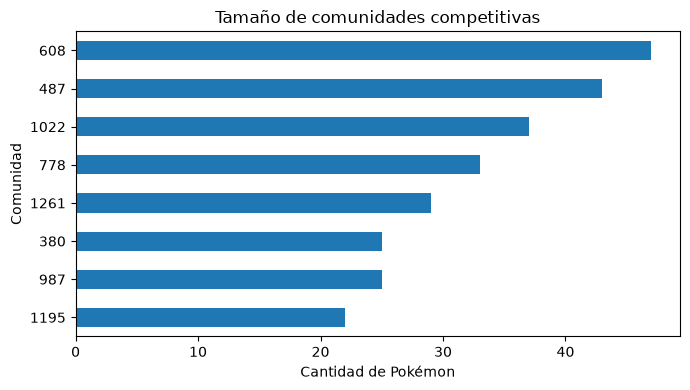

La comunidad 1195 aparece como una de las más relevantes de esta tabla, con una muestra que incluye primeape, exeggcute, girafarig y forretress. Esto no permite etiquetarla automáticamente como lluvia, stall, balance u otro arquetipo, porque la consulta no prueba ese estilo por sí sola. Lo que sí indica es que esos Pokémon se ubican en una zona densa de co-ocurrencia y merecen revisarse como posible core o grupo de apoyo mutuo.

In [10]:
res = df('''
CALL gds.louvain.stream('teammates') YIELD nodeId, communityId
WITH communityId, gds.util.asNode(nodeId) AS p
OPTIONAL MATCH (p)-[u:USED_IN]->(:Format {tier:'gen9ou'})
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
RETURN communityId AS comunidad,
       count(DISTINCT p) AS tamaño,
       round(avg(coalesce(u.usage, 0.0)) * 100) / 100.0 AS uso_promedio,
       collect(DISTINCT p.identifier)[..10] AS muestra_pokemon,
       collect(DISTINCT m.identifier)[..8] AS movimientos_frecuentes_en_muestra
ORDER BY uso_promedio DESC, tamaño DESC
LIMIT 8
''')
display(res)
if not res.empty:
    ax = res.sort_values('tamaño').plot.barh(
        x='comunidad', y='tamaño', legend=False, figsize=(7, 4)
    )
    ax.set_title('Tamaño de comunidades competitivas')
    ax.set_xlabel('Cantidad de Pokémon')
    ax.set_ylabel('Comunidad')
    plt.tight_layout()
    plt.show()
if not res.empty:
    fila = res.iloc[0]
    muestra = lista_texto(fila['muestra_pokemon'], max_items=4)
    display(Markdown(
        f"La comunidad {fila['comunidad']} aparece como una de las más relevantes de esta tabla, con una muestra que incluye {muestra}. "
        "Esto no permite etiquetarla automáticamente como lluvia, stall, balance u otro arquetipo, porque la consulta no prueba ese estilo por sí sola. "
        "Lo que sí indica es que esos Pokémon se ubican en una zona densa de co-ocurrencia y merecen revisarse como posible core o grupo de apoyo mutuo."
    ))


Una comunidad competitiva es un grupo de Pokémon que tienden a aparecer
conectados entre sí en la red de compañeros. En lenguaje de construcción de
equipos, estos grupos pueden parecerse a cores: conjuntos de piezas que se usan
juntas porque cubren debilidades, habilitan una misma estrategia o repiten un
patrón exitoso dentro del metajuego.

La tabla muestra el tamaño de cada comunidad, una muestra de sus Pokémon y
algunos movimientos frecuentes. Las comunidades más grandes no son
necesariamente mejores, pero sí indican zonas densas de co-ocurrencia. En la
práctica, esto ayuda a observar estilos de equipo que no se ven al mirar un
Pokémon aislado, como presión ofensiva, soporte defensivo, control de velocidad
o pivoteo.

La detección de comunidades sugiere patrones, pero no les asigna significado por
sí sola. Para afirmar que una comunidad corresponde a un arquetipo competitivo
concreto, todavía hay que revisar conjuntos de movimientos, objetos, roles y
partidas. El grafo muestra dónde mirar; la interpretación competitiva completa
requiere análisis humano.


### 4.5 Cadenas que explican por qué un Pokémon encaja

Las rutas relacionales conectan una pieza con recursos y compañeros. Este bloque
muestra cadenas acotadas entre Pokémon usados en OU, movimientos que ejecutan,
tipos de esos movimientos y compañeros frecuentes.


In [11]:
query = '''
MATCH (p:Pokemon)-[u:USED_IN]->(:Format {tier:'gen9ou'})
WITH p, u
ORDER BY u.usage DESC
LIMIT 12
MATCH (p)-[tm:TEAMMATE_OF]-(aliado:Pokemon)
OPTIONAL MATCH (p)-[:RUNS_MOVE]->(m:Move)
OPTIONAL MATCH (m)-[:MOVE_TYPE]->(mt:Type)
RETURN p.identifier AS pokemon,
       round(u.usage * 100) / 100.0 AS uso_smogon,
       m.identifier AS movimiento_usado,
       mt.identifier AS tipo_del_movimiento,
       aliado.identifier AS compañero_frecuente,
       round(coalesce(tm.pct, 0.0) * 100) / 100.0 AS co_uso
ORDER BY uso_smogon DESC, co_uso DESC
LIMIT 20
'''
res = df(query)
display(res)
if not res.empty:
    ejemplos = "; ".join(
        f"{r['pokemon']} usa {r['movimiento_usado']} ({r['tipo_del_movimiento']}) y aparece con {r['compañero_frecuente']}"
        for _, r in res.head(2).iterrows()
    )
    display(Markdown(
        f"Como ejemplo, la tabla muestra cadenas como: {ejemplos}. Estas rutas son útiles porque conectan una pieza con una herramienta concreta y con un compañero frecuente. "
        "La interpretación estratégica no depende solo del nombre del Pokémon, sino de cómo ese movimiento y esa relación de equipo ayudan a explicar por qué puede encajar en una construcción."
    ))


,pokemon,uso_smogon,movimiento_usado,tipo_del_movimiento,compañero_frecuente,co_uso
0,great-tusk,33.73,earthquake,ground,gholdengo,1604.8
1,great-tusk,33.73,stealth-rock,rock,gholdengo,1604.8
2,great-tusk,33.73,temper-flare,fire,gholdengo,1604.8
3,great-tusk,33.73,bulk-up,fighting,gholdengo,1604.8
4,great-tusk,33.73,stone-edge,rock,gholdengo,1604.8
5,great-tusk,33.73,headlong-rush,ground,gholdengo,1604.8
6,great-tusk,33.73,head-smash,rock,gholdengo,1604.8
7,great-tusk,33.73,ice-spinner,ice,gholdengo,1604.8
8,great-tusk,33.73,body-press,fighting,gholdengo,1604.8
9,great-tusk,33.73,close-combat,fighting,gholdengo,1604.8


Como ejemplo, la tabla muestra cadenas como: great-tusk usa earthquake (ground) y aparece con gholdengo; great-tusk usa stealth-rock (rock) y aparece con gholdengo. Estas rutas son útiles porque conectan una pieza con una herramienta concreta y con un compañero frecuente. La interpretación estratégica no depende solo del nombre del Pokémon, sino de cómo ese movimiento y esa relación de equipo ayudan a explicar por qué puede encajar en una construcción.

Estas cadenas muestran una de las ventajas más claras del grafo: permiten
explicar conexiones, no solo listar atributos. Cada fila une un Pokémon con un
movimiento usado, el tipo de ese movimiento y un compañero frecuente. Así se
puede pasar de una descripción simple, como "este Pokémon aparece en OU", a una
explicación más estratégica sobre qué herramienta aporta y con quién suele
combinarse.

Una cadena de relaciones no pretende resumir todo el rol de un Pokémon, pero sí
ofrece una pista interpretable. Si un Pokémon aparece asociado a cierto tipo de
movimiento y a un compañero recurrente, eso puede sugerir cobertura ofensiva,
apoyo defensivo, presión conjunta o una sinergia de construcción. La utilidad
práctica está en convertir datos dispersos en una explicación que pueda leerse
como parte de un plan de equipo.

El cuidado principal es que estas rutas son ejemplos acotados. No muestran todas
las razones por las que un Pokémon encaja en una estrategia ni reemplazan la
revisión de sets completos, turnos de juego o matchups. Funcionan como evidencia
relacional para iniciar la interpretación.


### 4.6 ¿El grafo descubre patrones que no se ven claramente en tablas?

La evidencia se resume con métricas ya calculadas por el archivo externo de ML.
El cuaderno no ejecuta ese archivo: solo muestra el resumen para mantener el
tiempo de ejecución controlado.


,experimento,variables,AUC,AP
0,Viabilidad OU,BST base,0.827,0.498
1,Viabilidad OU,Repertorio de movimientos + habilidades,0.857,0.584
2,Viabilidad OU,Grafo competitivo,0.986,0.970
3,Predicción de enlaces COMPATIBLE,Experimento externo reproducible,0.670,0.694


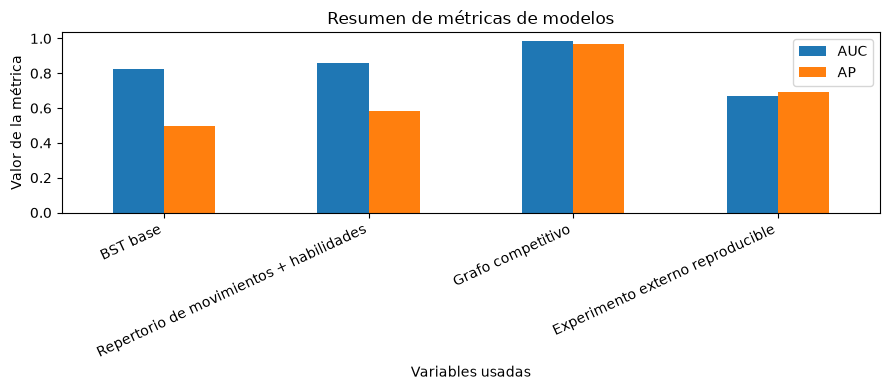

En las métricas de viabilidad OU, el punto de partida con BST base alcanza AUC=0.827 y AP=0.498, mientras que la versión con Grafo competitivo llega a AUC=0.986 y AP=0.970. La mejora sugiere que las relaciones del grafo agregan información útil frente a mirar solo atributos aislados. Al mismo tiempo, un valor tan alto debe leerse con cautela, porque las relaciones competitivas pueden estar muy cerca de la etiqueta de viabilidad que se busca predecir.

Los experimentos completos de ML se reproducen fuera de este cuaderno con analysis/graph_ml_integrated.py.


In [12]:
metricas_ml = pd.DataFrame([
    {"experimento": "Viabilidad OU", "variables": "BST base", "AUC": 0.827, "AP": 0.498},
    {"experimento": "Viabilidad OU", "variables": "Repertorio de movimientos + habilidades", "AUC": 0.857, "AP": 0.584},
    {"experimento": "Viabilidad OU", "variables": "Grafo competitivo", "AUC": 0.986, "AP": 0.970},
    {"experimento": "Predicción de enlaces COMPATIBLE", "variables": "Experimento externo reproducible", "AUC": 0.670, "AP": 0.694},
])

display(metricas_ml)
ax = metricas_ml.set_index('variables')[['AUC', 'AP']].plot.bar(figsize=(9, 4))
ax.set_title('Resumen de métricas de modelos')
ax.set_xlabel('Variables usadas')
ax.set_ylabel('Valor de la métrica')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()
base = metricas_ml.iloc[0]
grafo = metricas_ml[metricas_ml['variables'] == 'Grafo competitivo'].iloc[0]
display(Markdown(
    f"En las métricas de viabilidad OU, el punto de partida con {base['variables']} alcanza AUC={base['AUC']:.3f} y AP={base['AP']:.3f}, "
    f"mientras que la versión con {grafo['variables']} llega a AUC={grafo['AUC']:.3f} y AP={grafo['AP']:.3f}. "
    "La mejora sugiere que las relaciones del grafo agregan información útil frente a mirar solo atributos aislados. Al mismo tiempo, un valor tan alto debe leerse con cautela, "
    "porque las relaciones competitivas pueden estar muy cerca de la etiqueta de viabilidad que se busca predecir."
))

print("Los experimentos completos de ML se reproducen fuera de este cuaderno con analysis/graph_ml_integrated.py.")


Las métricas AUC y AP resumen qué tan bien un modelo distingue casos
positivos de negativos. En términos simples, valores más altos indican que el
modelo ordena mejor los ejemplos relevantes por encima de los no relevantes.
Aquí se comparan variables tabulares simples, como estadísticas base, contra
variables que incorporan información relacional del grafo.

El resultado sugiere que las conexiones competitivas agregan señal. Cuando se
incluyen relaciones del grafo, las métricas mejoran frente a usar solo atributos
aislados, lo que apoya la idea de que el grafo captura patrones que una tabla
plana no muestra con la misma claridad. Para el análisis estratégico, esto
significa que las relaciones entre Pokémon, movimientos, compañeros y formatos
pueden aportar información útil sobre viabilidad o comportamiento competitivo.

La interpretación debe ser cuidadosa, sobre todo cuando aparecen valores muy
altos. Si las relaciones competitivas usadas como variables están muy cerca de
la etiqueta que se quiere predecir, el modelo puede beneficiarse de información
demasiado directa. Por eso estas métricas son evidencia de que existe señal en
el grafo, pero no una prueba definitiva de generalización a otros formatos o
metajuegos futuros.


## 5. Machine Learning integrado

El bloque de ML se conserva como resumen de métricas. La lógica completa vive en
`analysis/graph_ml_integrated.py` y debe ejecutarse por separado cuando se quiera
reproducir el experimento completo.

El resumen compara:

- viabilidad OU con variables base de estadísticas,
- viabilidad OU agregando repertorio de movimientos y habilidades,
- viabilidad OU agregando señales del grafo competitivo,
- predicción de enlaces `COMPATIBLE` como experimento externo reproducible.

No se ejecuta el archivo completo dentro del cuaderno para evitar aumentar el
tiempo de `nbconvert` y para mantener separado el reporte narrativo del
experimento reproducible.


## 6. Conclusiones

El grafo integrado funciona como un motor de razonamiento competitivo porque
conecta recursos, roles y relaciones de equipo. La centralidad muestra qué
Pokémon organizan la red; la similitud por movimientos sugiere sustitutos; el
cuadro de tipos permite razonar sobre perfiles ofensivos y defensivos; las
comunidades de `TEAMMATE_OF` revelan cores; y las rutas heterogéneas explican
por qué una pieza encaja en una estrategia.

El aporte principal frente a una lectura tabular es relacional. Una tabla puede
ordenar por uso, ataque o velocidad; el grafo permite ver cómo una decisión se
conecta con compañeros, cobertura, respuestas defensivas y patrones de co-ocurrencia. Por eso
los resultados deben leerse como apoyo a decisiones estratégicas, no como una
lista automática de mejores Pokémon.

Como alcance temporal, las conclusiones corresponden a Gen 9 OU / Scarlet &
Violet / Smogon. Pokémon Champions puede cambiar el metajuego, por lo que una
extensión natural del proyecto es actualizar la capa competitiva con esos datos
y volver a evaluar centralidades, sustitutos, cores y métricas.


In [13]:
driver.close()
print('Conexión a Neo4j cerrada. Reporte integrado finalizado.')


Conexión a Neo4j cerrada. Reporte integrado finalizado.
